# - Name : Devarsh Vasani
# - ID - 202301251

In [ ]:
!pip install pandas
!pip install numpy
!pip install nltk
!pip install scikit-learn
!pip install torch
!pip install spacy



In [5]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import torch
import warnings
import torch.nn as nn

import spacy


In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])



In [ ]:
df = pd.read_csv('/fake_reviews_dataset.csv')

In [ ]:
def clean_text_spacy(text):
    doc = nlp(str(text).lower())

    tokens = [
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop and len(token.lemma_) > 2
    ]

    return ' '.join(tokens)

In [31]:
try:
    from tqdm import tqdm
    tqdm.pandas(desc="Cleaning reviews")
    df['clean_text'] = df['text_'].progress_apply(clean_text_spacy)
except ImportError:
    df['clean_text'] = df['text_'].apply(clean_text_spacy)

print("\nText cleaning completed!")

print("\nSample cleaned reviews:")
print("="*80)
for idx in df.head(3).index:
    print(f"\nOriginal: {df.loc[idx, 'text_'][:100]}...")
    print(f"Cleaned:  {df.loc[idx, 'clean_text'][:100]}...")
    print("-"*80)

Cleaning reviews: 100%|██████████| 40432/40432 [08:02<00:00, 83.77it/s]


Text cleaning completed!

Sample cleaned reviews:

Original: Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty...
Cleaned:  love sturdy comfortable love pretty...
--------------------------------------------------------------------------------

Original: love it, a great upgrade from the original.  I've had mine for a couple of years...
Cleaned:  love great upgrade original couple year...
--------------------------------------------------------------------------------

Original: This pillow saved my back. I love the look and feel of this pillow....
Cleaned:  pillow save love look feel pillow...
--------------------------------------------------------------------------------


In [40]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

print("TF-IDF Vectorizer initialized with parameters:")
print(f"  - Max features: 5000")
print(f"  - N-gram range: (1, 2) - unigrams + bigrams")
print(f"  - Min document frequency: 5")
print(f"  - Max document frequency: 0.8")
print(f"\nNote: spaCy lemmatization improves TF-IDF quality by:")
print(f"  - Grouping related words (e.g., 'run', 'running', 'runs' → 'run')")
print(f"  - Reducing vocabulary size while preserving meaning")
print(f"  - Improving feature consistency across documents")

TF-IDF Vectorizer initialized with parameters:
  - Max features: 5000
  - N-gram range: (1, 2) - unigrams + bigrams
  - Min document frequency: 5
  - Max document frequency: 0.8

Note: spaCy lemmatization improves TF-IDF quality by:
  - Grouping related words (e.g., 'run', 'running', 'runs' → 'run')
  - Reducing vocabulary size while preserving meaning
  - Improving feature consistency across documents


In [41]:
print("\nFitting TF-IDF vectorizer on lemmatized text...")
X_tfidf = tfidf.fit_transform(df['clean_text'])
print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"  - Number of samples: {X_tfidf.shape[0]:,}")
print(f"  - Number of features: {X_tfidf.shape[1]:,}")

print("\nConverting to dense array...")
X_tfidf_dense = X_tfidf.toarray()
print(f"Dense array shape: {X_tfidf_dense.shape}")
print(f"Memory size: {X_tfidf_dense.nbytes / 1024 / 1024:.2f} MB")


Fitting TF-IDF vectorizer on lemmatized text...
TF-IDF Matrix Shape: (40429, 5000)
  - Number of samples: 40,429
  - Number of features: 5,000

Converting to dense array...
Dense array shape: (40429, 5000)
Memory size: 1542.24 MB


In [42]:
feature_names = tfidf.get_feature_names_out()

lemma_examples = {
    'run': ['run', 'running', 'runs', 'ran'],
    'good': ['good', 'better', 'best'],
    'product': ['product', 'products'],
    'work': ['work', 'working', 'works', 'worked']
}
for lemma, variations in lemma_examples.items():
    found = [v for v in variations if v in feature_names]


In [43]:
# Task 1: Product category classification (multiclass)
categories = df['category'].unique()
category_to_idx = {cat: idx for idx, cat in enumerate(sorted(categories))}
y_category = df['category'].map(category_to_idx).values

print("Task 1: Product Category Classification")
print(f"Number of categories: {len(categories)}")
print(f"\nCategory mapping:")
for cat, idx in sorted(category_to_idx.items(), key=lambda x: x[1]):
    print(f"  {idx}: {cat}")

print(f"\nLabel distribution:")
unique, counts = np.unique(y_category, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} samples")

Task 1: Product Category Classification
Number of categories: 10

Category mapping:
  0: Books_5
  1: Clothing_Shoes_and_Jewelry_5
  2: Electronics_5
  3: Home_and_Kitchen_5
  4: Kindle_Store_5
  5: Movies_and_TV_5
  6: Pet_Supplies_5
  7: Sports_and_Outdoors_5
  8: Tools_and_Home_Improvement_5
  9: Toys_and_Games_5

Label distribution:
  Class 0: 4,370 samples
  Class 1: 3,847 samples
  Class 2: 3,987 samples
  Class 3: 4,056 samples
  Class 4: 4,730 samples
  Class 5: 3,588 samples
  Class 6: 4,253 samples
  Class 7: 3,946 samples
  Class 8: 3,858 samples
  Class 9: 3,794 samples


In [44]:
label_to_idx = {'OR': 0, 'CG': 1}
y_fake = df['label'].map(label_to_idx).values

print("Task 2: Fake Review Detection")
print(f"\nLabel mapping:")
print(f"  0: OR (Genuine/Original)")
print(f"  1: CG (Fake/Computer Generated)")

print(f"\nLabel distribution:")
unique, counts = np.unique(y_fake, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "Genuine" if label == 0 else "Fake"
    print(f"  {label_name} ({label}): {count:,} samples ({count/len(y_fake)*100:.2f}%)")

Task 2: Fake Review Detection

Label mapping:
  0: OR (Genuine/Original)
  1: CG (Fake/Computer Generated)

Label distribution:
  Genuine (0): 20,216 samples (50.00%)
  Fake (1): 20,213 samples (50.00%)


In [45]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_tfidf_dense, y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print("Task 1: Category Classification Split")
print(f"  Training set: {X_train_cat.shape[0]:,} samples")
print(f"  Test set: {X_test_cat.shape[0]:,} samples")
print(f"  Feature dimension: {X_train_cat.shape[1]:,}")

Task 1: Category Classification Split
  Training set: 32,343 samples
  Test set: 8,086 samples
  Feature dimension: 5,000


In [46]:
# Task 2: Fake detection
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(
    X_tfidf_dense, y_fake,
    test_size=0.2,
    random_state=42,
    stratify=y_fake
)

print("\nTask 2: Fake Detection Split")
print(f"  Training set: {X_train_fake.shape[0]:,} samples")
print(f"  Test set: {X_test_fake.shape[0]:,} samples")
print(f"  Feature dimension: {X_train_fake.shape[1]:,}")


Task 2: Fake Detection Split
  Training set: 32,343 samples
  Test set: 8,086 samples
  Feature dimension: 5,000


In [47]:
print("Converting to PyTorch tensors for Task 1...")
X_train_cat_tensor = torch.FloatTensor(X_train_cat)
X_test_cat_tensor = torch.FloatTensor(X_test_cat)
y_train_cat_tensor = torch.LongTensor(y_train_cat)
y_test_cat_tensor = torch.LongTensor(y_test_cat)

print(f"  X_train shape: {X_train_cat_tensor.shape}")
print(f"  X_test shape: {X_test_cat_tensor.shape}")
print(f"  y_train shape: {y_train_cat_tensor.shape}")
print(f"  y_test shape: {y_test_cat_tensor.shape}")

Converting to PyTorch tensors for Task 1...
  X_train shape: torch.Size([32343, 5000])
  X_test shape: torch.Size([8086, 5000])
  y_train shape: torch.Size([32343])
  y_test shape: torch.Size([8086])


In [48]:
print("Converting to PyTorch tensors for Task 2...")
X_train_fake_tensor = torch.FloatTensor(X_train_fake)
X_test_fake_tensor = torch.FloatTensor(X_test_fake)
y_train_fake_tensor = torch.FloatTensor(y_train_fake).unsqueeze(1)
y_test_fake_tensor = torch.FloatTensor(y_test_fake).unsqueeze(1)

print(f"  X_train shape: {X_train_fake_tensor.shape}")
print(f"  X_test shape: {X_test_fake_tensor.shape}")
print(f"  y_train shape: {y_train_fake_tensor.shape}")
print(f"  y_test shape: {y_test_fake_tensor.shape}")

print("\nPyTorch tensors created successfully!")

Converting to PyTorch tensors for Task 2...
  X_train shape: torch.Size([32343, 5000])
  X_test shape: torch.Size([8086, 5000])
  y_train shape: torch.Size([32343, 1])
  y_test shape: torch.Size([8086, 1])

PyTorch tensors created successfully!


In [52]:
save_path = 'processed_data.pt'

torch.save({
    # Task 1: Category classification
    'X_train_cat': X_train_cat_tensor,
    'X_test_cat': X_test_cat_tensor,
    'y_train_cat': y_train_cat_tensor,
    'y_test_cat': y_test_cat_tensor,

    # Task 2: Fake detection
    'X_train_fake': X_train_fake_tensor,
    'X_test_fake': X_test_fake_tensor,
    'y_train_fake': y_train_fake_tensor,
    'y_test_fake': y_test_fake_tensor,

    # Metadata
    'num_categories': len(categories),
    'category_mapping': category_to_idx,
    'num_features': X_train_cat.shape[1],
    'feature_names': feature_names
}, save_path)


In [3]:
data = torch.load('/processed_data.pt', weights_only=False)

X_train = data['X_train_cat']
X_test = data['X_test_cat']
y_train = data['y_train_cat']
y_test = data['y_test_cat']
num_classes = data['num_categories']
category_mapping = data['category_mapping']

print(f"Data loaded successfully!")
print(f"\nDataset Information:")
print(f"  Training samples: {X_train.shape[0]:,}")
print(f"  Test samples: {X_test.shape[0]:,}")
print(f"  Input features: {X_train.shape[1]:,}")
print(f"  Number of classes: {num_classes}")

print(f"\nCategory Mapping:")
for cat, idx in sorted(category_mapping.items(), key=lambda x: x[1]):
    print(f"  {idx}: {cat}")

Data loaded successfully!

Dataset Information:
  Training samples: 32,344
  Test samples: 8,087
  Input features: 5,000
  Number of classes: 10

Category Mapping:
  0: Books_5
  1: Clothing_Shoes_and_Jewelry_5
  2: Electronics_5
  3: Home_and_Kitchen_5
  4: Kindle_Store_5
  5: Movies_and_TV_5
  6: Pet_Supplies_5
  7: Sports_and_Outdoors_5
  8: Tools_and_Home_Improvement_5
  9: Toys_and_Games_5


In [6]:
class CategoryClassifier(nn.Module):

    def __init__(self, input_dim, hidden_dim1=256, hidden_dim2=128, num_classes=10, dropout=0.3):
        super(CategoryClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(hidden_dim2, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

# Initialize model
input_dim = X_train.shape[1]
model = CategoryClassifier(input_dim=input_dim, num_classes=num_classes)

print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
CategoryClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 1,314,442
Trainable parameters: 1,314,442


In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss Function: CrossEntropyLoss")
print("Optimizer: Adam (lr=0.001)")

Loss Function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


In [9]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created:
  Batch size: 64
  Training batches: 506
  Test batches: 127


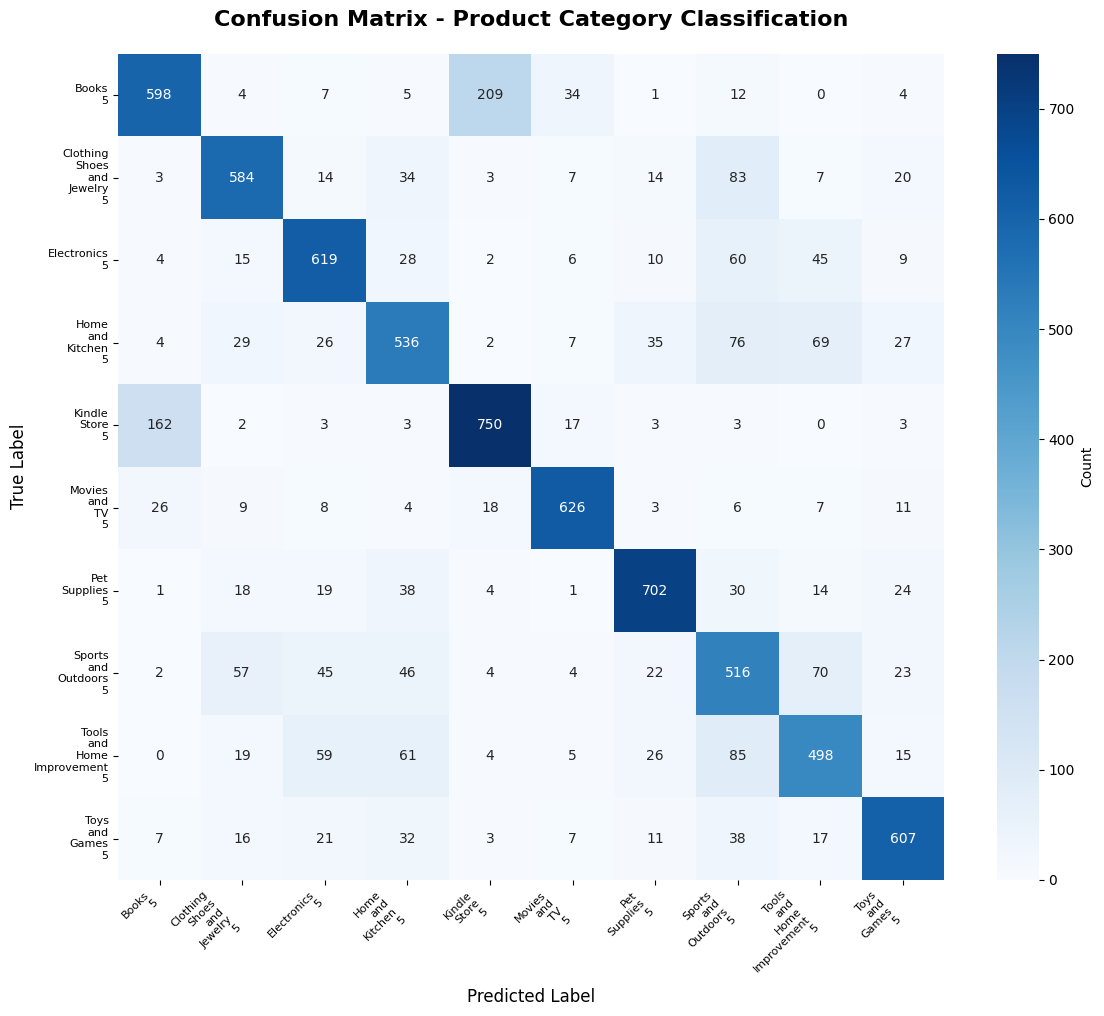

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label][pred_label] += 1

    return cm

def plot_confusion_matrix(cm, num_classes, category_mapping):

    plt.figure(figsize=(12, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                cbar_kws={'label': 'Count'})

    plt.title('Confusion Matrix - Product Category Classification',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)

    idx_to_category = {v: k for k, v in category_mapping.items()}
    labels = [idx_to_category[i].replace('_', '\n') for i in range(num_classes)]
    plt.xticks(np.arange(num_classes) + 0.5, labels, rotation=45, ha='right', fontsize=8)
    plt.yticks(np.arange(num_classes) + 0.5, labels, rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

    return cm

cm = create_confusion_matrix(all_labels, all_predictions, num_classes)
cm = plot_confusion_matrix(cm, num_classes, category_mapping)

In [34]:
# Create datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created:
  Batch size: 64
  Training batches: 506
  Test batches: 127


In [36]:
def calculate_metrics_binary(y_true, y_pred):

    y_true = y_true.cpu().numpy() if torch.is_tensor(y_true) else y_true
    y_pred = y_pred.cpu().numpy() if torch.is_tensor(y_pred) else y_pred

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'tp': int(tp),
        'fp': int(fp),
        'tn': int(tn),
        'fn': int(fn)
    }

print("Manual metrics function defined!")

Manual metrics function defined!


In [37]:
model.eval()
all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        probabilities = torch.sigmoid(outputs)
        predicted = (probabilities > 0.5).float()

        all_predictions.extend(predicted.tolist())
        all_labels.extend(batch_y.tolist())
        all_probabilities.extend(probabilities.tolist())

metrics = calculate_metrics_binary(all_labels, all_predictions)

print("\n" + "=" * 70)
print("FAKE REVIEW DETECTION RESULTS")
print("=" * 70)
print(f"\nOverall Metrics:")
print(f"  Accuracy:    {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f"  Precision:   {metrics['precision']:.4f}")
print(f"  Recall:      {metrics['recall']:.4f}")
print(f"  F1-Score:    {metrics['f1_score']:.4f}")
print(f"  Specificity: {metrics['specificity']:.4f}")
print("=" * 70)

AttributeError: 'list' object has no attribute 'flatten'

In [38]:
print("\nConfusion Matrix Components:")
print("=" * 70)
print(f"  True Positives (TP):  {metrics['tp']:,} (Correctly identified fake reviews)")
print(f"  True Negatives (TN):  {metrics['tn']:,} (Correctly identified genuine reviews)")
print(f"  False Positives (FP): {metrics['fp']:,} (Genuine wrongly flagged as fake)")
print(f"  False Negatives (FN): {metrics['fn']:,} (Fake wrongly flagged as genuine)")
print("=" * 70)

print(f"\nAdditional Insights:")
print(f"  Total test samples: {len(all_labels):,}")
print(f"  Correctly classified: {metrics['tp'] + metrics['tn']:,}")
print(f"  Misclassified: {metrics['fp'] + metrics['fn']:,}")
print(f"  Error rate: {(metrics['fp'] + metrics['fn'])/len(all_labels)*100:.2f}%")


Confusion Matrix Components:


KeyError: 'tp'

In [ ]:
fake_reviews = df[df['label'] == 'CG']['text_']
genuine_reviews = df[df['label'] == 'OR']['text_']

fake_text = ' '.join(fake_reviews.astype(str))
genuine_text = ' '.join(genuine_reviews.astype(str))

print(f"Fake Reviews:")
print(f"  Count: {len(fake_reviews):,}")
print(f"  Total characters: {len(fake_text):,}")
print(f"  Average length: {len(fake_text)/len(fake_reviews):.2f} characters")

print(f"\nGenuine Reviews:")
print(f"  Count: {len(genuine_reviews):,}")
print(f"  Total characters: {len(genuine_text):,}")
print(f"  Average length: {len(genuine_text)/len(genuine_reviews):.2f} characters")

In [ ]:
wordcloud_fake = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='Reds',
    max_words=150,
    relative_scaling=0.5,
    min_font_size=10,
    contour_width=2,
    contour_color='darkred'
).generate(fake_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in FAKE Reviews (Computer Generated)',
          fontsize=22, fontweight='bold', pad=20, color='darkred')
plt.tight_layout(pad=0)
plt.show()

print("Word cloud for fake reviews generated!")

In [ ]:
wordcloud_genuine = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='Greens',
    max_words=150,
    relative_scaling=0.5,
    min_font_size=10,
    contour_width=2,
    contour_color='darkgreen'
).generate(genuine_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_genuine, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in GENUINE Reviews (Original)',
          fontsize=22, fontweight='bold', pad=20, color='darkgreen')
plt.tight_layout(pad=0)
plt.show()

print("Word cloud for genuine reviews generated!")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('FAKE Reviews', fontsize=18, fontweight='bold', color='darkred', pad=10)

axes[1].imshow(wordcloud_genuine, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('GENUINE Reviews', fontsize=18, fontweight='bold', color='darkgreen', pad=10)

plt.suptitle('Word Cloud Comparison: Fake vs Genuine Reviews',
             fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
def get_top_words(text, n=30, min_length=3):
    """
    Extract top N most frequent words

    Args:
        text: Input text
        n: Number of top words to return
        min_length: Minimum word length

    Returns:
        List of (word, count) tuples
    """
    # Extract words (alphanumeric only)
    words = re.findall(r'\b\w+\b', text.lower())

    # Filter by length
    words = [w for w in words if len(w) >= min_length]

    # Count frequencies
    counter = Counter(words)

    return counter.most_common(n)

# Get top words
fake_top_words = get_top_words(fake_text, n=30)
genuine_top_words = get_top_words(genuine_text, n=30)

print("Top 30 words in FAKE reviews:")
print("=" * 60)
for i, (word, count) in enumerate(fake_top_words, 1):
    print(f"{i:2d}. {word:<20} {count:>8,}")

print("\n\nTop 30 words in GENUINE reviews:")
print("=" * 60)
for i, (word, count) in enumerate(genuine_top_words, 1):
    print(f"{i:2d}. {word:<20} {count:>8,}")

In [ ]:
# Compare top 15 words side by side
fake_words = [w for w, c in fake_top_words[:15]]
fake_counts = [c for w, c in fake_top_words[:15]]

genuine_words = [w for w, c in genuine_top_words[:15]]
genuine_counts = [c for w, c in genuine_top_words[:15]]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Fake reviews
axes[0].barh(fake_words, fake_counts, color='#ff6b6b', edgecolor='darkred', linewidth=1.5)
axes[0].set_title('Top 15 Words in FAKE Reviews', fontsize=14, fontweight='bold', color='darkred')
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Genuine reviews
axes[1].barh(genuine_words, genuine_counts, color='#4ecdc4', edgecolor='darkgreen', linewidth=1.5)
axes[1].set_title('Top 15 Words in GENUINE Reviews', fontsize=14, fontweight='bold', color='darkgreen')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Word Frequency Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# Find words more common in fake vs genuine reviews
fake_word_freq = dict(fake_top_words)
genuine_word_freq = dict(genuine_top_words)

# Words heavily biased toward fake reviews
fake_biased = []
for word, fake_count in fake_top_words[:30]:
    genuine_count = genuine_word_freq.get(word, 0)
    if fake_count > 0:
        ratio = fake_count / (genuine_count + 1)  # +1 to avoid division by zero
        fake_biased.append((word, fake_count, genuine_count, ratio))

# Sort by ratio
fake_biased.sort(key=lambda x: x[3], reverse=True)

print("Words MORE COMMON in FAKE reviews:")
print("=" * 80)
print(f"{'Word':<20} {'Fake Count':>12} {'Genuine Count':>15} {'Ratio':>10}")
print("-" * 80)
for word, fake_cnt, gen_cnt, ratio in fake_biased[:15]:
    print(f"{word:<20} {fake_cnt:>12,} {gen_cnt:>15,} {ratio:>10.2f}x")